In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("gold_ml_price_features.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (29708, 17)


,product_id,price,name,breadcrumb_section,breadcrumb_category,breadcrumb_subcategory,producer_id,eshop,sales,warranty,spec_summary,rating,in_stock,review_count,avg_rating,recommendation_rate,complaint_rate
0,3809599,8499.00,La Piccola Gold,Household and Personal Appliances,Coffee Makers and Presses,Lever,2845.0,Alza,24,24 months,"Lever Coffee Machine - pressure 18bar, water ...",4.9,t,5.0,4.9,1.00,NaN
1,3837335,549.00,KEMO repellent for mice and rodents,Car & Motorcycle,Car Accessories,Game Scarers and Repellers,15917.0,AutoMoto,3495,24 months,"- High frequency, 12V",4.3,t,29.0,4.3,0.80,0.0036
2,3753577,589.54,Philips Alcyone 77113/31/16,"House, Hobby and Garden",Light Bulbs and Lighting,NaN,1611.0,Alza,16,60 months,"Spot Lighting - LED, ceiling light, suspended ...",0.0,t,0.0,NaN,NaN,NaN
3,3809147,629.00,Epson T7605 Light Cyan,Computers and Laptops,Printers and Scanners,Toners & Inks,1301.0,Alza,14,24 months,"Cartridge - for SureColor SC-P600, 2400 pages",5.0,t,0.0,5.0,1.00,NaN
4,3837346,109.00,Spray against martens 200ml,Car & Motorcycle,Car Accessories,Game Scarers and Repellers,8610.0,AutoMoto,3385,24 months,"Marten Repellents Marten repellent, 200ml",4.5,t,19.0,4.5,0.84,0.0003


## Basic info

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29708 entries, 0 to 29707
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              29708 non-null  int64  
 1   price                   29708 non-null  float64
 2   name                    29708 non-null  str    
 3   breadcrumb_section      29708 non-null  str    
 4   breadcrumb_category     29707 non-null  str    
 5   breadcrumb_subcategory  27387 non-null  str    
 6   producer_id             29707 non-null  float64
 7   eshop                   29708 non-null  str    
 8   sales                   29708 non-null  int64  
 9   warranty                29708 non-null  str    
 10  spec_summary            29708 non-null  str    
 11  rating                  29708 non-null  float64
 12  in_stock                29708 non-null  str    
 13  review_count            29685 non-null  float64
 14  avg_rating              15282 non-null  float64
 

# Null summary

In [3]:
df.isnull().sum().sort_values(ascending=False)

complaint_rate            18947
recommendation_rate       14426
avg_rating                14426
breadcrumb_subcategory     2321
review_count                 23
breadcrumb_category           1
producer_id                   1
spec_summary                  0
in_stock                      0
rating                        0
product_id                    0
warranty                      0
price                         0
eshop                         0
breadcrumb_section            0
name                          0
sales                         0
dtype: int64

# Price distribution

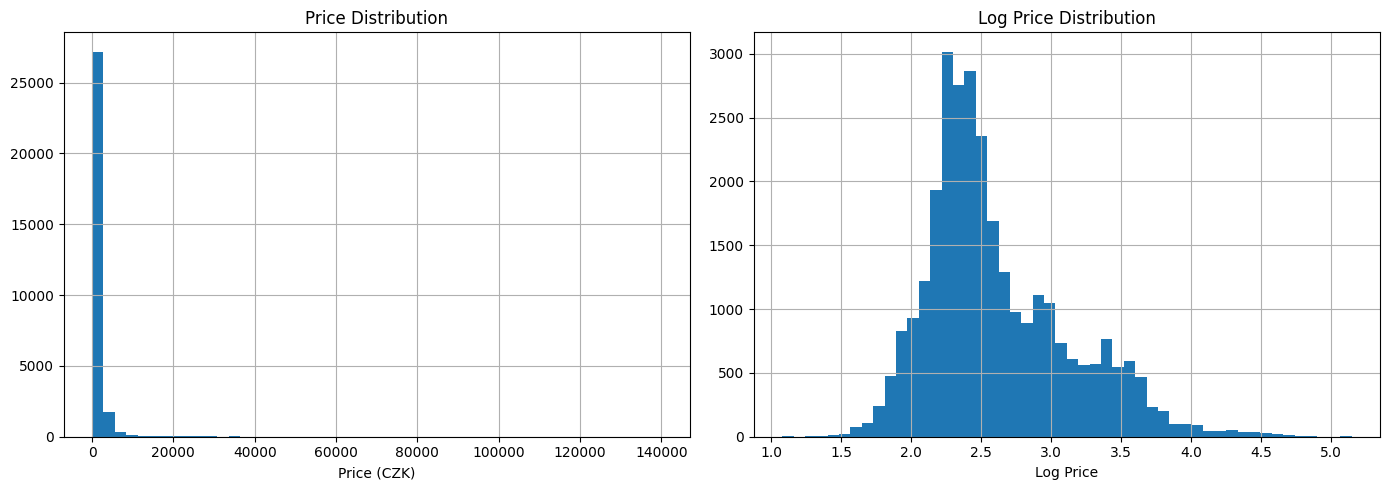

count     29708.000000
mean       1078.079578
std        3242.016758
min          12.000000
25%         179.500000
50%         299.000000
75%         812.527500
max      139989.990000
Name: price, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['price'].hist(bins=50, ax=axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (CZK)')

df['price'].apply(lambda x: np.log10(x)).hist(bins=50, ax=axes[1]) 
axes[1].set_title('Log Price Distribution')
axes[1].set_xlabel('Log Price')

plt.tight_layout()
plt.show()

print(df['price'].describe())


# Correlation heatmap

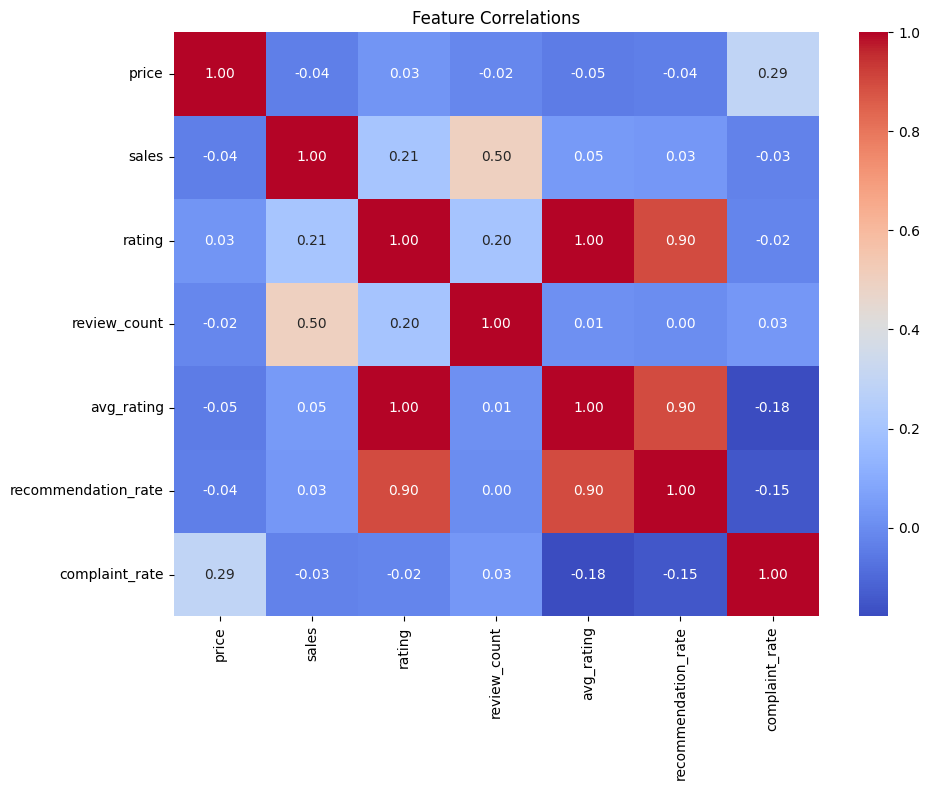

In [5]:
numeric_cols = ['price', 'sales', 'rating', 'review_count', 
                'avg_rating', 'recommendation_rate', 'complaint_rate']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlations')
plt.tight_layout()
plt.show()

# Price by section

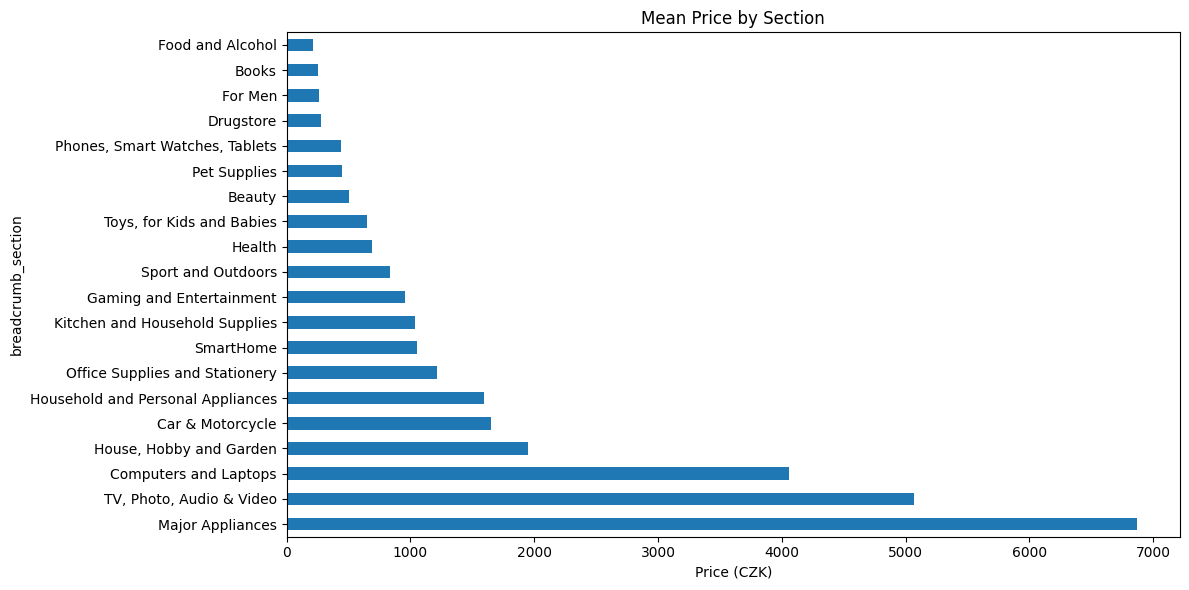

In [6]:
section_stats = (df.groupby('breadcrumb_section')['price']
    .agg(['median', 'mean', 'count'])
    .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
section_stats['mean'].plot(kind='barh', ax=ax)
ax.set_title('Mean Price by Section')
ax.set_xlabel('Price (CZK)')
plt.tight_layout()
plt.show()

In [7]:
# Price by eshop

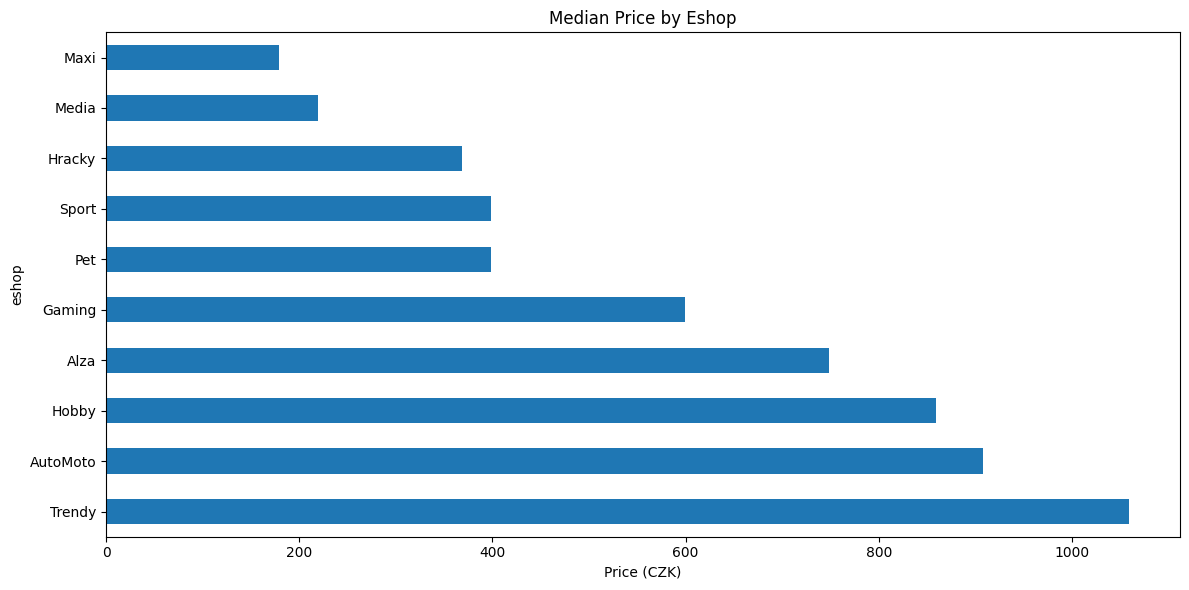

In [8]:
eshop_stats = df.groupby('eshop')['price'].agg(['median', 'count']).sort_values('median', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
eshop_stats['median'].plot(kind='barh', ax=ax)
ax.set_title('Median Price by Eshop')
ax.set_xlabel('Price (CZK)')
plt.tight_layout()
plt.show()

# Rating vs Price

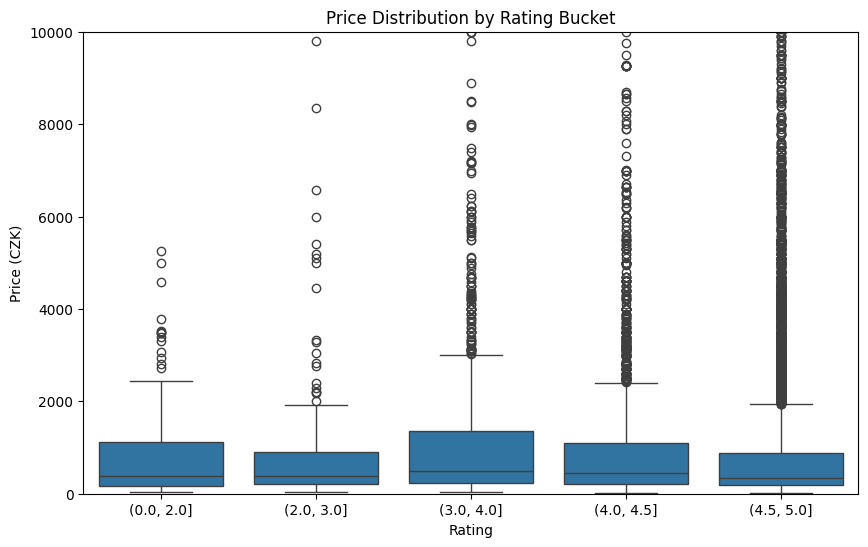

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=pd.cut(df['rating'], bins=[0, 2, 3, 4, 4.5, 5]), y='price')
plt.ylim(0, 10000)
plt.title('Price Distribution by Rating Bucket')
plt.xlabel('Rating')
plt.ylabel('Price (CZK)')
plt.show()

# Sales vs price

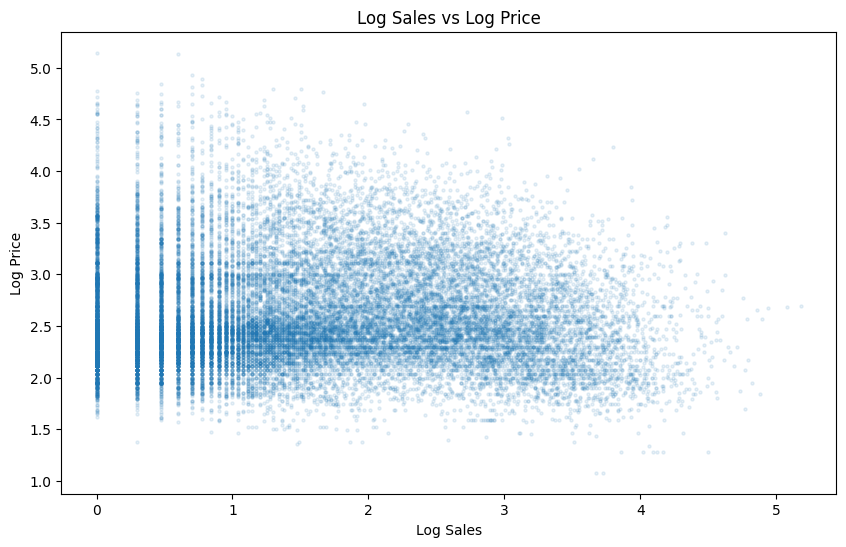

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(np.log10(df['sales']), np.log10(df['price']), alpha=0.1, s=5)
plt.xlabel('Log Sales')
plt.ylabel('Log Price')
plt.title('Log Sales vs Log Price')
plt.show()

# Warranty value counts:

In [11]:
df['warranty'].value_counts().head(10)

warranty
24 months     28713
36 months       421
60 months       370
120 months       86
48 months        36
360 months       24
84 months        19
25 months        11
72 months         8
144 months        7
Name: count, dtype: int64